# GBM Simulator — Visual Verification
Loads the simulated paths and checks correctness visually.

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

In [2]:
DATA_DIR = Path('..') / 'data'

paths = torch.load(DATA_DIR / 'gbm_paths.pt', weights_only=True)   # (M, N+1)
meta  = json.loads((DATA_DIR / 'gbm_paths.json').read_text())

S0    = meta['S0']
mu    = meta['mu']
sigma = meta['sigma']
T     = meta['T']
N     = meta['N']
M     = meta['M']

print(f'Loaded {M:,} paths × {N+1} time-points  |  S0={S0}, mu={mu}, sigma={sigma}, T={T}')

Loaded 100,000 paths × 253 time-points  |  S0=100.0, mu=0.05, sigma=0.2, T=1.0


## 1 · Sample paths (n=20)

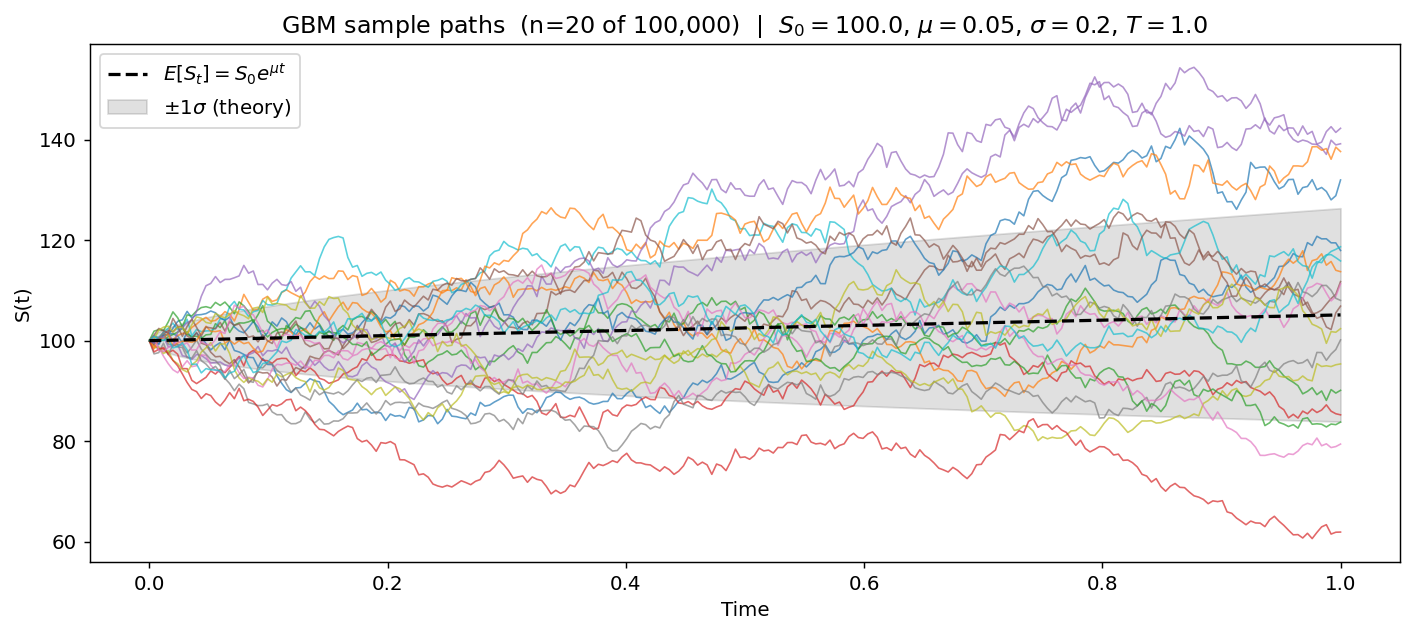

In [3]:
N_SAMPLE = 20
t = torch.linspace(0, T, N + 1).numpy()

torch.manual_seed(0)
idx = torch.randperm(M)[:N_SAMPLE]
sample = paths[idx].numpy()          # (20, N+1)

# Theoretical mean and ±1σ band
mean_theory = S0 * np.exp(mu * t)
std_theory  = mean_theory * np.sqrt(np.exp(sigma**2 * t) - 1)

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(N_SAMPLE):
    ax.plot(t, sample[i], lw=0.9, alpha=0.7)

ax.plot(t, mean_theory, 'k--', lw=1.8, label=r'$E[S_t] = S_0 e^{\mu t}$')
ax.fill_between(t,
                mean_theory - std_theory,
                mean_theory + std_theory,
                alpha=0.12, color='black', label=r'$\pm 1\sigma$ (theory)')

ax.set_xlabel('Time')
ax.set_ylabel('S(t)')
ax.set_title(f'GBM sample paths  (n={N_SAMPLE} of {M:,})  |  '
             rf'$S_0={S0}$, $\mu={mu}$, $\sigma={sigma}$, $T={T}$')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.show()

## 2 · Terminal distribution $S_T$ vs log-normal theory

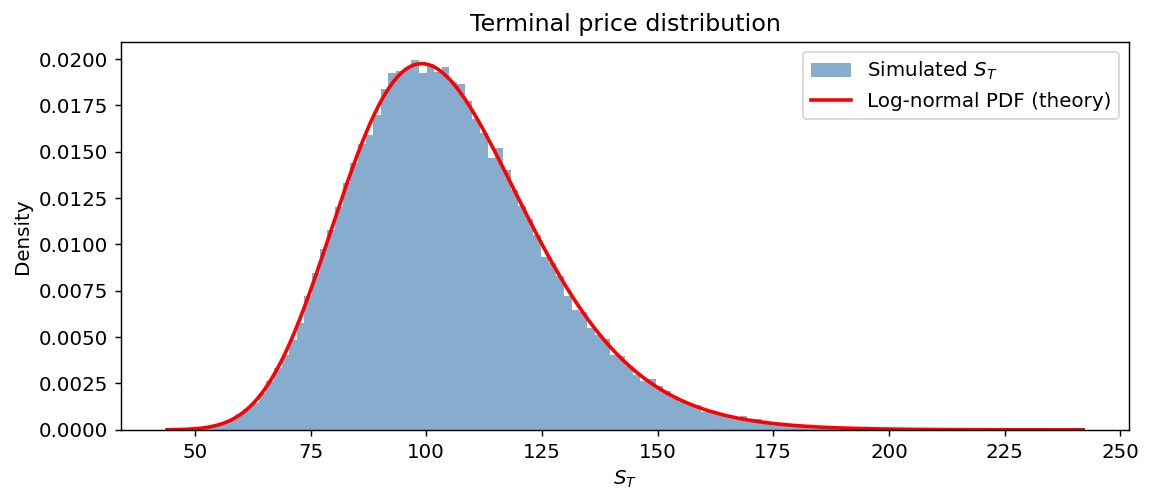

In [4]:
S_T = paths[:, -1].numpy()

# Log-normal PDF parameters
log_mu    = np.log(S0) + (mu - 0.5 * sigma**2) * T
log_sigma = sigma * np.sqrt(T)
x = np.linspace(S_T.min(), S_T.max(), 500)
pdf_theory = (1 / (x * log_sigma * np.sqrt(2 * np.pi))) * \
             np.exp(-0.5 * ((np.log(x) - log_mu) / log_sigma)**2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(S_T, bins=120, density=True, color='steelblue', alpha=0.65, label='Simulated $S_T$')
ax.plot(x, pdf_theory, 'r-', lw=2, label='Log-normal PDF (theory)')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Density')
ax.set_title('Terminal price distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Moment checks

In [5]:
E_sim  = S_T.mean()
E_th   = S0 * np.exp(mu * T)
std_sim = S_T.std()
std_th  = E_th * np.sqrt(np.exp(sigma**2 * T) - 1)

print(f'              Simulated       Theory')
print(f'E[S_T]     {E_sim:>12.4f}   {E_th:>10.4f}')
print(f'Std[S_T]   {std_sim:>12.4f}   {std_th:>10.4f}')
print(f'Rel error (mean) : {abs(E_sim - E_th)/E_th:.4%}')
print(f'Rel error (std)  : {abs(std_sim - std_th)/std_th:.4%}')

              Simulated       Theory
E[S_T]         105.1259     105.1271
Std[S_T]        21.2449      21.2374
Rel error (mean) : 0.0011%
Rel error (std)  : 0.0353%
